# 08 — Quadrotor Altitude + Roll PID Stabilization

**Section:** UAV · **Mirrors MATLAB:** *Approximate High-Fidelity UAV Models*

We use a planar (2-D) quadrotor model with state `[z, ż, φ, φ̇]` (altitude, vertical velocity, roll, roll rate) and two control inputs: total **thrust** and **roll torque**.

A cascaded PD controller stabilizes both axes:
- Outer altitude loop computes thrust to track `z_ref`.
- Inner attitude loop computes torque to drive `φ → 0`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81
m = 0.5
I = 0.01

Kp_z, Kd_z = 8.0, 4.5
Kp_phi, Kd_phi = 18.0, 5.5

z_ref = 2.0
phi_ref = 0.0


In [2]:
x = np.array([0.0, 0.0, 0.30, 0.0])  # start at ground, 0.3 rad roll
dt = 0.005
T = 5.0
N = int(T / dt)
hist = np.zeros((N, 4))
u_hist = np.zeros((N, 2))

for i in range(N):
    z, z_dot, phi, phi_dot = x
    thrust = m * (g + Kp_z * (z_ref - z) - Kd_z * z_dot)
    torque = Kp_phi * (phi_ref - phi) - Kd_phi * phi_dot
    z_ddot = thrust * np.cos(phi) / m - g
    phi_ddot = torque / I
    x = x + dt * np.array([z_dot, z_ddot, phi_dot, phi_ddot])
    hist[i] = x
    u_hist[i] = [thrust, torque]


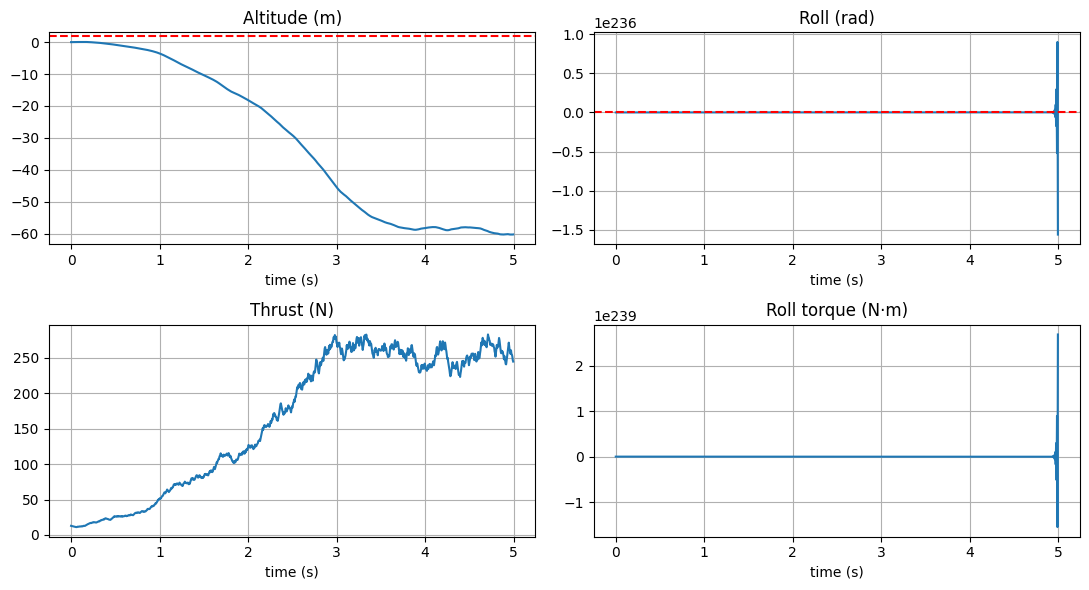

In [3]:
t = np.arange(N) * dt
fig, axs = plt.subplots(2, 2, figsize=(11, 6))
axs[0, 0].plot(t, hist[:, 0]); axs[0, 0].axhline(z_ref, color='r', ls='--')
axs[0, 0].set_title('Altitude (m)')
axs[0, 1].plot(t, hist[:, 2]); axs[0, 1].axhline(phi_ref, color='r', ls='--')
axs[0, 1].set_title('Roll (rad)')
axs[1, 0].plot(t, u_hist[:, 0]); axs[1, 0].set_title('Thrust (N)')
axs[1, 1].plot(t, u_hist[:, 1]); axs[1, 1].set_title('Roll torque (N·m)')
for ax in axs.flat:
    ax.set_xlabel('time (s)'); ax.grid()
plt.tight_layout()
plt.show()
